# B22 — Grover in Qiskit

**Track B — the SDK.** A10 built Grover out of two lines of NumPy: multiply by a
diagonal of $\pm1$, then reflect through the mean. This notebook builds the same
algorithm out of Qiskit objects, and then asks the questions that only become
askable once it is a *circuit*: what does the oracle cost, what does the diffuser
compile to, and what does noise do to a peak you have to hit exactly.

---

## The one-sentence version

`grover_operator()` hands you one Grover iteration as a `QuantumCircuit`; apply it
$\approx\tfrac{\pi}{4}\sqrt{N}$ times to a uniform superposition and measure —
but **apply it more times than that and it gets worse**, which is the part of the
story most SDK tutorials leave out and this notebook draws twice.

## The API warning, first

Every Grover tutorial written before 2024 starts with

```python
from qiskit.algorithms import Grover, AmplificationProblem   # ImportError
```

`qiskit.algorithms` was spun out of the SDK in 1.0 and the successor package is
no longer supported by IBM. It is **not installed here and must not be added**.
The modern route is lower-level and, honestly, better teaching: you assemble the
iteration yourself from library pieces.

| Dead (0.x / 1.x tutorials) | Current, Qiskit 2.5 |
|---|---|
| `from qiskit.algorithms import Grover` | `from qiskit.circuit.library import grover_operator` |
| `AmplificationProblem(oracle, is_good_state=...)` | build the oracle circuit yourself |
| `GroverOperator(oracle)` (the class) | `grover_operator(oracle)` (the **function**) |
| `from qiskit.circuit.library import PhaseOracle` | `PhaseOracleGate` |
| `qiskit.circuit.classicalfunction` | `PhaseOracleGate` / `BitFlipOracleGate` |
| `execute(qc, backend)` | `SamplerV2`, or `Statevector` for the exact answer |

The `BlueprintCircuit` classes (`GroverOperator`, `QFT`, `EfficientSU2`, …) still
import in 2.5, but they transpile worse and are on their way out. Prefer the
function forms.

## What A10 already gave us

| A10, in NumPy | here, in Qiskit |
|---|---|
| `d = np.ones(N); d[marked] = -1` | `PhaseOracleGate("a & b & ~c & d")` |
| `psi = 2*psi.mean() - psi` | the `zero_reflection` inside `grover_operator()` |
| $H^{\otimes n}(I - 2|0\rangle\langle0|)H^{\otimes n}$ | what that reflection actually compiles to |
| $G^k|s\rangle$ by repeated multiplication | `Statevector.evolve(G)` in a loop |
| $P(k) = \sin^2\big((2k+1)\theta\big)$ | still exactly true, and asserted below |
| "the multi-controlled Z is expensive to decompose" | **Figure 5 measures it** |

## What this notebook adds that A10 could not

A10 knew the amplitudes exactly and for free. Here the algorithm is a *circuit*,
so three new facts come into view:

1. **The oracle has a gate count.** A10 counted "one query". Figure 5 counts CNOTs,
   and the answer is that a single iteration on 12 qubits costs over a thousand of
   them — so $\sqrt N$ *queries* is not $\sqrt N$ *gates*.
2. **Measurement gives you one bitstring.** Figure 4 replaces A10's exact
   probabilities with 2048 actual shots and honest binomial error bars.
3. **Noise flattens the peak — and moves it.** Section 5 turns on a depolarizing
   channel and the optimal iteration count *shifts earlier*, because past a point
   another iteration destroys more amplitude than it creates.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.circuit.library import (BitFlipOracleGate, PhaseOracleGate,
                                    grover_operator)
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer.noise import NoiseModel, depolarizing_error

style.use()

SEED = backends.seed_for("B22")
rng = np.random.default_rng(SEED)

# A hardware-like basis. Aer executes `mcx` natively, so transpiling to the
# simulator leaves the multi-controlled gates intact and every gate count comes
# out flattering. Every count in this notebook goes through this basis instead.
BASIS = ["rz", "sx", "x", "cx"]

print("qiskit", qiskit.__version__, "  seed", SEED)

qiskit 2.5.1   seed 20260826


---

## Part 1 — the oracle, three ways

A10's oracle was a NumPy array: `d = np.ones(16); d[11] = -1`. In a circuit it has
to be *built*, and Qiskit gives three routes to the same $16\times16$ diagonal.

We mark exactly what A10 marked, so the two notebooks are comparable line by line:
the predicate $q_0 = 1,\; q_1 = 1,\; q_2 = 0,\; q_3 = 1$, which little-endian
(CLAUDE.md §3) is index $11$, printed `|1011>`.

**Route 1 — by hand.** A phase flip on one basis state is an $X$ sandwich around a
multi-controlled $Z$: put $X$ on every qubit that should be $0$, apply an MCZ
(which flips the sign of $|1{\cdots}1\rangle$ only), undo the $X$s. Qiskit has no
`mcz`, so the idiom is $H$ on the target, `mcx`, $H$ back.

**Route 2 — `PhaseOracleGate`.** New in Qiskit 1.3/2.0, and the replacement for
both the old `PhaseOracle` class and `qiskit.circuit.classicalfunction`. You hand
it a boolean expression as a *string* and it synthesises the circuit. Variables are
bound to qubits in order of first appearance, so `a` is qubit 0.

**Route 3 — `BitFlipOracleGate` plus an ancilla.** The oracle in its textbook form
computes $f(x)$ into an extra qubit: $|x\rangle|y\rangle \to |x\rangle|y \oplus
f(x)\rangle$. Put that ancilla in $|-\rangle$ and the bit flip becomes a *phase*
flip on the input register — A08's phase kickback, which is where the $-1$ in
Grover's oracle actually comes from physically.

In [2]:
N_QUBITS = 4
N = 2 ** N_QUBITS
MARKED = [11]                      # exactly A10's marked index
EXPR4 = "(a & b & ~c & d)"         # a=q0, b=q1, c=q2, d=q3  ->  q=1,1,0,1


def mcz(qc, qubits):
    """Multi-controlled Z on `qubits`: flips the sign of |1...1> and nothing else.

    Qiskit has no `mcz` instruction. H on the target turns the MCX's bit flip
    into a phase flip, which is the same trick A03/A08 used on one qubit.
    """
    *controls, target = qubits
    qc.h(target)
    qc.mcx(controls, target)
    qc.h(target)
    return qc


def oracle_by_hand(n, marked_index):
    """ROUTE 1 - X sandwich around an MCZ. One marked basis state."""
    qc = QuantumCircuit(n, name="oracle (hand)")
    zeros = [q for q in range(n) if not (marked_index >> q) & 1]
    if zeros:
        qc.x(zeros)
    mcz(qc, list(range(n)))
    if zeros:
        qc.x(zeros)
    return qc


def oracle_from_expression(expr):
    """ROUTE 2 - PhaseOracleGate, straight from a boolean expression."""
    gate = PhaseOracleGate(expr)
    qc = QuantumCircuit(gate.num_qubits, name="oracle (expr)")
    qc.append(gate, range(gate.num_qubits))
    return qc


def oracle_with_ancilla(expr):
    """ROUTE 3 - BitFlipOracleGate writing into an ancilla held in |->.

    The ancilla starts |0>, is taken to |-> by X then H, and the bit flip
    |y> -> |y XOR f(x)> then multiplies the whole branch by (-1)^f(x): phase
    kickback. The ancilla ends where it started and is never entangled with the
    register, which is exactly why this is a legitimate phase oracle.
    """
    gate = BitFlipOracleGate(expr)
    n = gate.num_qubits - 1
    qc = QuantumCircuit(gate.num_qubits, name="oracle (kickback)")
    qc.x(n)
    qc.h(n)
    qc.append(gate, range(gate.num_qubits))
    qc.h(n)
    qc.x(n)
    return qc


HAND = oracle_by_hand(N_QUBITS, MARKED[0])
EXPRC = oracle_from_expression(EXPR4)
ANC = oracle_with_ancilla(EXPR4)

diag_hand = np.diag(Operator(HAND).data).real
diag_expr = np.diag(Operator(EXPRC).data).real
# The ancilla version acts on 5 qubits; the ancilla returns to |0>, so the
# register block is the top-left 16x16 corner of the 32x32 unitary.
U_anc = Operator(ANC).data
diag_anc = np.diag(U_anc).real[:N]

print("marked index:", MARKED, " label: |" + format(MARKED[0], "04b") + ">")
print("route 1 (hand)     :", diag_hand.astype(int))
print("route 2 (expression):", diag_expr.astype(int))
print("route 3 (kickback) :", diag_anc.astype(int))
print("\nall three agree     :",
      np.allclose(diag_hand, diag_expr) and np.allclose(diag_hand, diag_anc))
print("diagonal, +-1 only  :", np.allclose(np.abs(diag_expr), 1.0))
print("off-diagonal is zero:",
      np.allclose(Operator(EXPRC).data - np.diag(diag_expr), 0))
print("the ancilla comes back clean (no entanglement with the register):",
      np.allclose(U_anc[:N, N:], 0) and np.allclose(U_anc[N:, :N], 0))

marked index: [11]  label: |1011>
route 1 (hand)     : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
route 2 (expression): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
route 3 (kickback) : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

all three agree     : True
diagonal, +-1 only  : True
off-diagonal is zero: True
the ancilla comes back clean (no entanglement with the register): True


Three constructions, one diagonal — and it is *the same array A10 typed by hand*.
The point of showing all three is that they fail differently: route 1 needs you to
get the endianness of the $X$ sandwich right, route 2 needs you to get the variable
order right, and route 3 needs the ancilla prepared in $|-\rangle$ and returned
clean. Any of those three mistakes produces a circuit that runs fine and marks the
wrong thing.

### Figure 1 — the oracle as a circuit, as a matrix, and as a diagonal

First: the three circuits. Note how little is in them — the expression oracle is
a single opaque box until you `.decompose()` it, and the kickback oracle spends two
gates each side just parking the ancilla in $|-\rangle$.

Then, left: the full $16\times16$ unitary. It is diagonal, real, and $\pm1$: a
permutation of signs and nothing else. Right: that diagonal as signed bars,
which is exactly A10's Figure 1 panel 2 — one bar pushed below the axis, fifteen
untouched, and *no probability moved anywhere*.

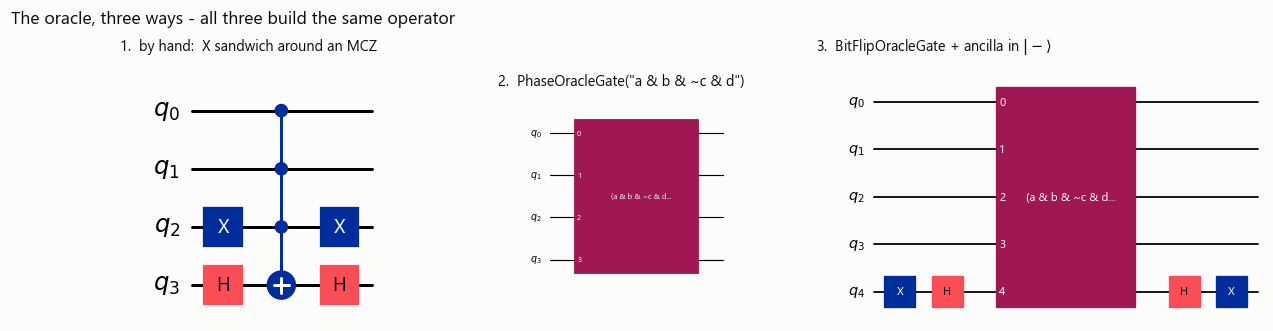

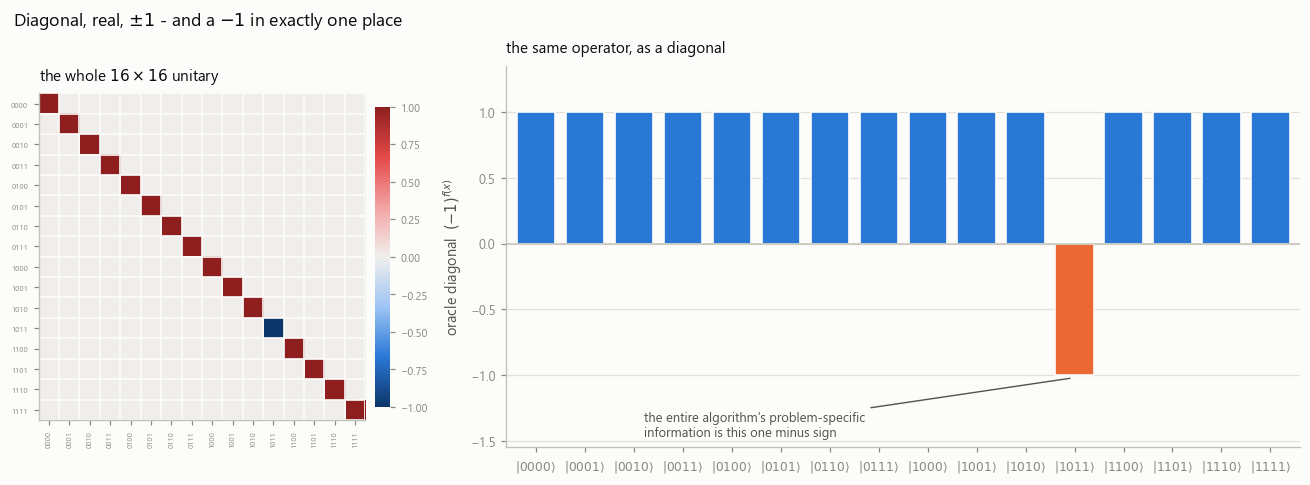

gate counts, transpiled to ['rz', 'sx', 'x', 'cx']
  hand        qubits 4   depth  26   cx  14   total  31
  expression  qubits 4   depth  26   cx  14   total  31
  kickback    qubits 5   depth  78   cx  36   total  96


In [3]:
# Two figures, not one grid. Qiskit's mpl circuit drawer forces an equal aspect
# ratio on whatever axes it is handed, which starves every other panel in the
# same gridspec of height (CLAUDE.md section 2). Keeping circuits in their own
# figure is the reliable way to compose them with anything else.
fig, axes = plt.subplots(1, 3, figsize=(12.2, 2.9),
                         gridspec_kw={"width_ratios": [1.15, 0.55, 1.45]})
for axc, circ, name in zip(
        axes,
        [HAND, EXPRC, ANC],
        ["1.  by hand:  X sandwich around an MCZ",
         "2.  PhaseOracleGate(\"a & b & ~c & d\")",
         "3.  BitFlipOracleGate + ancilla in $|-\\rangle$"]):
    circ.draw("mpl", ax=axc, style={"backgroundcolor": style.SURFACE})
    axc.set_title("", loc="center")          # qiskit writes the centred title
    axc.set_title(name, loc="left", fontsize=9.5)
fig.suptitle("The oracle, three ways - all three build the same operator",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

fig, (axM, axB) = plt.subplots(1, 2, figsize=(11.8, 4.3),
                               gridspec_kw={"width_ratios": [0.72, 1.75]})
grid.matrix(axM, Operator(EXPRC).data, part="re", annot=False, tick_size=5.0,
            title="the whole $16\\times16$ unitary")

grid.signed_bars(axB, diag_expr, highlight=MARKED[0], mean=False,
                 ylabel="oracle diagonal  $(-1)^{f(x)}$", tick_every=1)
axB.set_ylim(-1.55, 1.35)
grid.annotate(axB, "the entire algorithm's problem-specific\n"
                   "information is this one minus sign",
              xy=(MARKED[0], -1.02), xytext=(2.2, -1.38), color=style.INK_2)
axB.set_title("the same operator, as a diagonal", loc="left", fontsize=10)

fig.suptitle("Diagonal, real, $\\pm1$ - and a $-1$ in exactly one place",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("gate counts, transpiled to", BASIS)
for circ, name in [(HAND, "hand"), (EXPRC, "expression"), (ANC, "kickback")]:
    t = transpile(circ, basis_gates=BASIS, optimization_level=1,
                  seed_transpiler=SEED)
    print(f"  {name:11} qubits {circ.num_qubits}   depth {t.depth():3d}   "
          f"cx {t.count_ops().get('cx', 0):3d}   total {t.size():3d}")

---

## Part 2 — `grover_operator()`, and what is inside it

One Grover iteration is
$$G = D \cdot U_f, \qquad D = 2|s\rangle\langle s| - I .$$

`grover_operator(oracle)` returns that as a `QuantumCircuit`. Three things about
the call are worth knowing:

- It is a **function**, not a class. `GroverOperator` (the `BlueprintCircuit`) still
  exists in 2.5 and still works, but the function form is what the library is
  moving to and it transpiles better.
- The `state_preparation` argument defaults to $H^{\otimes n}$. Pass something else
  and you get **amplitude amplification** — the generalisation A10 verified
  numerically at the end, where the reflection is about $A|0\rangle$ for an
  arbitrary $A$.
- The `zero_reflection` argument defaults to $I - 2|0\rangle\langle 0|$, built as
  the $X^{\otimes n}\!\cdot$ MCZ $\cdot X^{\otimes n}$ sandwich. That is *exactly*
  A10's `diffuser_from_gates`, including the fact that it comes out as $-D$ — and
  Qiskit fixes the sign with a `global phase: π` on the circuit rather than an
  extra gate, because a global phase costs nothing.

So the drawn circuit below is A10's third diffuser construction, assembled by the
library instead of by us.

In [4]:
ORACLE_C = EXPRC                       # the PhaseOracleGate route, from here on
G4 = grover_operator(ORACLE_C)
G4_bar = grover_operator(ORACLE_C, insert_barriers=True)

print("grover_operator returns a", type(G4).__name__,
      "on", G4.num_qubits, "qubits, named", repr(G4.name))
print("global phase:", G4.global_phase, "  (= pi: the -D that A10 also hit)")
print("top-level ops:", dict(G4.count_ops()))

# ---- the same operator, built in raw NumPy the A10 way --------------------
H1 = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)


def all_qubits(U, n):
    out = np.array([[1.0 + 0j]])
    for _ in range(n):
        out = np.kron(out, U)
    return out


ORACLE_NP = np.ones(N)
ORACLE_NP[MARKED] = -1.0
S_VEC = np.ones(N) / np.sqrt(N)
D_NP = 2.0 * np.outer(S_VEC, S_VEC) - np.eye(N)      # 2|s><s| - I
G_NP = D_NP @ np.diag(ORACLE_NP)                     # one A10 iteration

G_QK = Operator(G4).data
print("\nQiskit's grover_operator == A10's  D @ diag(oracle) ?",
      np.allclose(G_QK, G_NP))
print("max |Qiskit - NumPy| over all 256 entries:",
      f"{np.max(np.abs(G_QK - G_NP)):.3e}")

# G is a product of two reflections, so it is a ROTATION: unitary, but NOT its
# own inverse (each reflection is, their product is not - that asymmetry is the
# entire over-rotation story).
print("\nG unitary            :", np.allclose(G_QK.conj().T @ G_QK, np.eye(N)))
print("G its own inverse?   :", np.allclose(G_QK @ G_QK, np.eye(N)),
      "  <- a rotation, not a reflection")
ev = np.linalg.eigvals(G_QK)
theta4 = np.arcsin(np.sqrt(len(MARKED) / N))
print(f"eigenphases of G (deg): "
      f"{sorted(np.round(np.degrees(np.angle(np.unique(np.round(ev, 9)))), 3))}")
print(f"2*theta = {np.degrees(2*theta4):.3f} deg   "
      "<- the rotation angle, sitting in G's spectrum")

grover_operator returns a QuantumCircuit on 4 qubits, named 'Q'
global phase: 3.141592653589793   (= pi: the -D that A10 also hit)
top-level ops: {'h': 10, 'x': 8, 'Phase Oracle': 1, 'mcx': 1}

Qiskit's grover_operator == A10's  D @ diag(oracle) ? True
max |Qiskit - NumPy| over all 256 entries: 1.573e-15

G unitary            : True
G its own inverse?   : False   <- a rotation, not a reflection
eigenphases of G (deg): [np.float64(-28.955), np.float64(28.955), np.float64(180.0)]
2*theta = 28.955 deg   <- the rotation angle, sitting in G's spectrum


That eigenphase line is worth a pause. $G$'s spectrum contains $e^{\pm 2i\theta}$,
and $\theta$ is the thing you need to know in order to stop at the right time.
Reading an eigenphase off a unitary is exactly what phase estimation does — which
is why B23 is the next notebook, and why "quantum counting" is the standard fix for
Grover's most annoying limitation.

### Figure 2 — one iteration, drawn and multiplied out

First: the circuit `grover_operator()` produced, with barriers marking the four
stages — oracle, $H^{\otimes n}$, the zero reflection, $H^{\otimes n}$ back.

Then the same iteration as matrices. $U_f$ is the diagonal from Figure 1. $D$ is
dense and, unusually for a quantum operator, has a *very* readable structure:
$2/N$ everywhere off the diagonal and $2/N - 1$ on it. Their product is $G$. The
fourth panel is the difference between what Qiskit built and what A10 built —
plotted on a $10^{-16}$ scale, because that is all that is there.

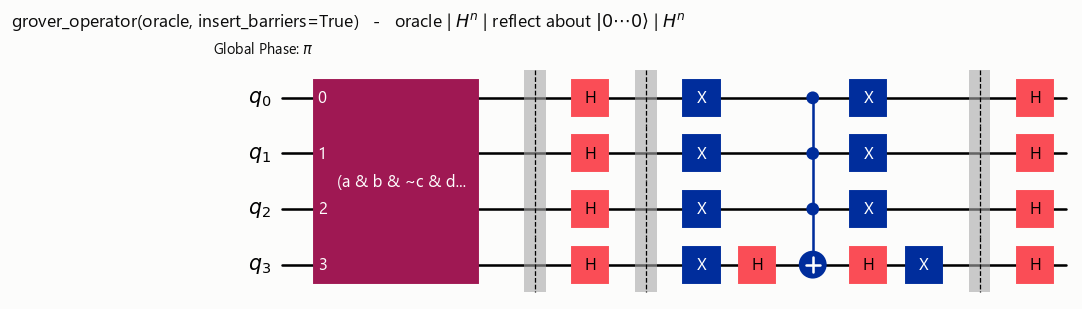

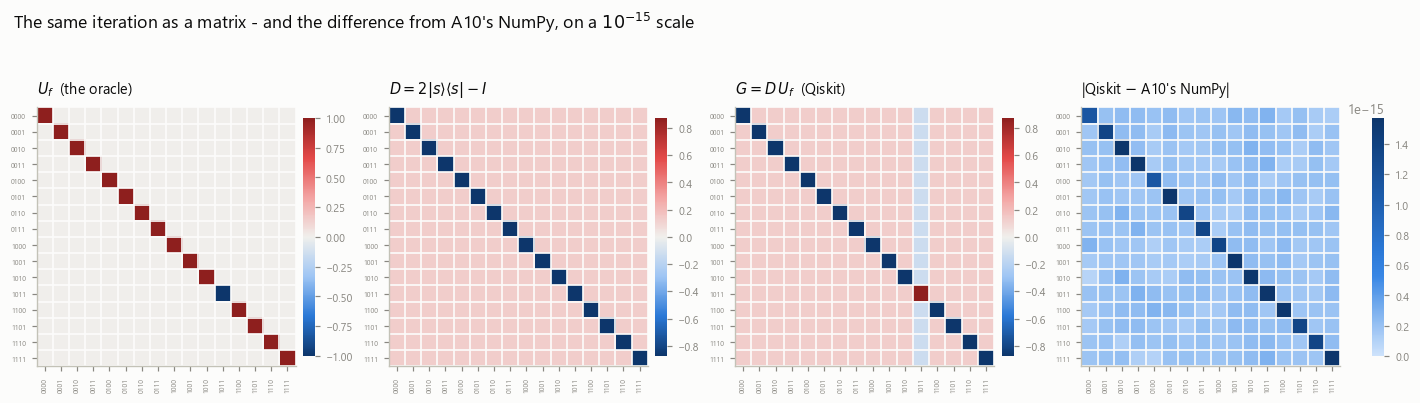

D off-diagonal entry = 2/N = 0.1250   (Qiskit: +0.1250-0.0000j before the oracle's sign)
largest disagreement anywhere between Qiskit and NumPy: 1.573e-15
that is 7.1 machine epsilons - i.e. the same operator, differently assembled.


In [5]:
fig, axc = plt.subplots(1, 1, figsize=(11.6, 2.7))
G4_bar.draw("mpl", ax=axc, style={"backgroundcolor": style.SURFACE})
axc.set_title("", loc="center")
fig.suptitle("grover_operator(oracle, insert_barriers=True)   -   "
             "oracle | $H^n$ | reflect about $|0{\\cdots}0\\rangle$ | $H^n$",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

DIFF = np.abs(G_QK - G_NP)
panels = [(np.diag(ORACLE_NP), "re", r"$U_f$  (the oracle)", None),
          (D_NP, "re", r"$D = 2|s\rangle\langle s| - I$", None),
          (G_QK.real, "re", r"$G = D\,U_f$  (Qiskit)", None),
          (DIFF, "abs", "|Qiskit $-$ A10's NumPy|", max(DIFF.max(), 1e-18))]
fig, axes = plt.subplots(1, 4, figsize=(12.8, 3.9))
for axm, (M, part, name, vmax) in zip(axes, panels):
    grid.matrix(axm, M, part=part, annot=False, vmax=vmax, tick_size=4.6)
    axm.set_title(name, loc="left", fontsize=9.5)

fig.suptitle("The same iteration as a matrix - and the difference from A10's "
             "NumPy, on a $10^{-15}$ scale", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"D off-diagonal entry = 2/N = {2/N:.4f}   "
      f"(Qiskit: {G_QK[0, 1]:+.4f} before the oracle's sign)")
print(f"largest disagreement anywhere between Qiskit and NumPy: "
      f"{DIFF.max():.3e}")
print(f"that is {DIFF.max()/np.finfo(float).eps:.1f} machine epsilons - i.e. "
      "the same operator, differently assembled.")

---

## Part 3 — the Grover heatmap

Now the picture this notebook exists for.

Run the algorithm on $N = 64$ (six qubits) and record the **whole statevector**
after every iteration, not just the marked amplitude. Stack those vectors into a
matrix: one row per iteration, one column per basis state. Colour it.

The marked column brightens. That is the algorithm. But keep going past the
optimum — we run to $k = 36$, six times too far — and the marked column *dims
again*, then brightens, then dims, forever. The sixty-three unmarked columns do the
opposite in lockstep, because probability has to go somewhere.

We do it twice:

- **Top row, $M = 1$.** Marked item 37, printed `|100101>` — the same item A10's
  Figure 3 used, so the numbers are directly comparable.
- **Bottom row, $M = 4$.** An oracle that only looks at qubits 0–3 and ignores
  qubits 4 and 5, so it marks $2^2 = 4$ items at once: 5, 21, 37, 53. Four times as
  many solutions means $\sin\theta = \sqrt{M/N}$ doubles, the rotation per step
  doubles, and **the whole pattern oscillates twice as fast**. The optimal $k$ drops
  from 6 to 3.

### Figure 3 — iteration × basis state

A note on the middle column: the amplitudes here are all *real* (a real oracle and
a real diffuser acting on a real start state never produce a complex amplitude), so
the middle panel plots **signed amplitude** on a diverging colormap. It shows
something the probability panel cannot: at $k = 12$ the marked amplitude is not
small, it is **negative**. The algorithm has rotated past the target and out the
other side.

In [6]:
N6 = 6
DIM6 = 2 ** N6
KMAX = 36

EXPR6 = "(a & ~b & c & ~d & ~e & f)"     # q0..q5 = 1,0,1,0,0,1  ->  index 37
EXPR6_M4 = "(a & ~b & c & ~d)"           # ignores q4, q5  ->  marks 4 items


def marked_oracle(expr, n_total, on_qubits=None):
    """A phase oracle from an expression, optionally embedded in a wider register.

    Embedding a 4-variable oracle in a 6-qubit circuit is how you get an oracle
    with several solutions without writing an OR of four clauses: the two qubits
    the predicate never mentions are free, so 2**2 basis states satisfy it.
    """
    gate = PhaseOracleGate(expr)
    qc = QuantumCircuit(n_total)
    qc.append(gate, on_qubits if on_qubits is not None
              else range(gate.num_qubits))
    return qc


def marked_indices(oracle_circ):
    """Read the marked set straight off the oracle's diagonal - no assumptions."""
    d = np.diag(Operator(oracle_circ).data).real
    return [int(i) for i in np.where(d < 0)[0]]


def uniform_circuit(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    return qc


def trajectory(oracle_circ, kmax):
    """Every statevector from k = 0 to k = kmax, as rows of a real array.

    Statevector.evolve applies the circuit to the state we already have, so this
    is kmax applications of G in total rather than sum(k) - the same trick A10's
    grover_states used with a NumPy loop.
    """
    n = oracle_circ.num_qubits
    G = grover_operator(oracle_circ)
    sv = Statevector(uniform_circuit(n))
    rows = [sv.data.copy()]
    for _ in range(kmax):
        sv = sv.evolve(G)
        rows.append(sv.data.copy())
    out = np.array(rows)
    assert np.allclose(out.imag, 0.0), "Grover keeps the amplitudes real"
    return out.real


def analytic(k, n_items, m_items):
    """A10's closed form: P(k) = sin^2((2k+1) theta), sin(theta) = sqrt(M/N)."""
    th = np.arcsin(np.sqrt(m_items / n_items))
    return np.sin((2 * np.asarray(k) + 1) * th) ** 2


def best_k(n_items, m_items):
    th = np.arcsin(np.sqrt(m_items / n_items))
    return int(np.round(np.pi / (4 * th) - 0.5))


ORACLE6 = marked_oracle(EXPR6, N6)
ORACLE6_M4 = marked_oracle(EXPR6_M4, N6, on_qubits=[0, 1, 2, 3])
MARK6 = marked_indices(ORACLE6)
MARK6_M4 = marked_indices(ORACLE6_M4)

TRAJ = trajectory(ORACLE6, KMAX)
TRAJ_M4 = trajectory(ORACLE6_M4, KMAX)
P_HIT = (TRAJ[:, MARK6] ** 2).sum(axis=1)
P_HIT_M4 = (TRAJ_M4[:, MARK6_M4] ** 2).sum(axis=1)

K_OPT = best_k(DIM6, 1)
K_OPT_M4 = best_k(DIM6, len(MARK6_M4))
K_WORST = int(np.argmin(P_HIT))

print("M = 1  marked:", MARK6, "=", [format(i, "06b") for i in MARK6])
print("M = 4  marked:", MARK6_M4, "=", [format(i, "06b") for i in MARK6_M4])
print(f"\noptimal k:  M=1 -> {K_OPT}   M=4 -> {K_OPT_M4}")
print(f"P at the optimum:  M=1 -> {P_HIT[K_OPT]:.6f}   "
      f"M=4 -> {P_HIT_M4[K_OPT_M4]:.6f}")
print(f"worst k over 0..{KMAX} (M=1): k = {K_WORST}, P = {P_HIT[K_WORST]:.6f} "
      f"(a random guess would give {1/DIM6:.6f})")
print("\nstatevector matches sin^2((2k+1)theta) at every k:",
      np.allclose(P_HIT, analytic(np.arange(KMAX + 1), DIM6, 1), atol=1e-12),
      "and for M = 4:",
      np.allclose(P_HIT_M4, analytic(np.arange(KMAX + 1), DIM6, 4), atol=1e-12))

M = 1  marked: [37] = ['100101']
M = 4  marked: [5, 21, 37, 53] = ['000101', '010101', '100101', '110101']

optimal k:  M=1 -> 6   M=4 -> 3
P at the optimum:  M=1 -> 0.996586   M=4 -> 0.961319
worst k over 0..36 (M=1): k = 12, P = 0.000071 (a random guess would give 0.015625)

statevector matches sin^2((2k+1)theta) at every k: True and for M = 4: True


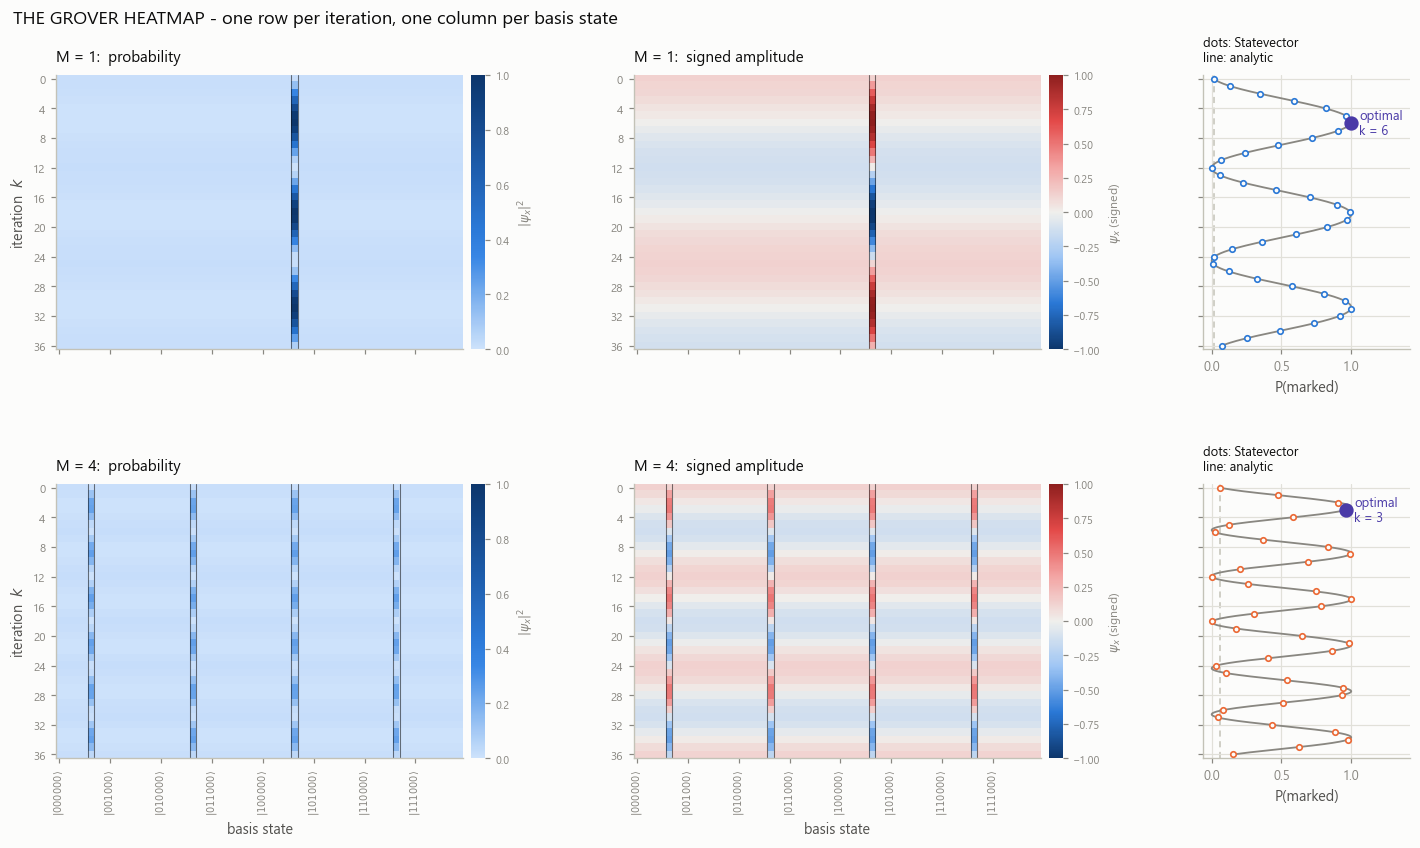

  k   P(marked), M=1   marked amplitude   P(marked), M=4
  0         0.015625          +0.125000         0.062500
  1         0.134827          +0.367187         0.472656
  2         0.343895          +0.586426         0.908447
  3         0.591380          +0.769012         0.961319
  4         0.816377          +0.903536         0.581704
  5         0.963515          +0.981588         0.125492
  6         0.996586          +0.998291         0.020381
  7         0.907449          +0.952601         0.364913
  8         0.718042          +0.847374         0.836089
  9         0.474976          +0.689185         0.992182
 10         0.238068          +0.487923         0.686854
 11         0.065620          +0.256165         0.206351
 12         0.000071          +0.008397         0.001143
 13         0.057550          -0.239896         0.263614
 18         0.994347          -0.997169         0.005706
 24         0.020063          -0.141644         0.033850
 30         0.956958          +

In [7]:
def heat(ax, data, *, part, marked, kmax, cbar_label):
    """One heatmap: rows = iteration k, columns = basis state."""
    if part == "prob":
        im = ax.imshow(data ** 2, cmap=style.SEQ, vmin=0, vmax=1,
                       aspect="auto", interpolation="nearest", origin="upper")
    else:
        im = ax.imshow(data, cmap=style.DIV, vmin=-1, vmax=1, aspect="auto",
                       interpolation="nearest", origin="upper")
    ax.set_xticks(range(0, DIM6, 8))
    ax.set_xticklabels([grid.ket(format(i, "06b")) for i in range(0, DIM6, 8)],
                       rotation=90, fontsize=6.5)
    ax.set_yticks(range(0, kmax + 1, 4))
    ax.set_yticklabels([str(k) for k in range(0, kmax + 1, 4)], fontsize=7.5)
    ax.set_ylabel("iteration  $k$")
    ax.grid(False)
    # A hairline either side of every marked column: at 64 columns one column is
    # under two pixels wide and the eye needs help finding it.
    for m in marked:
        ax.axvline(m - 0.5, color=style.INK, lw=0.7, alpha=0.55)
        ax.axvline(m + 0.5, color=style.INK, lw=0.7, alpha=0.55)
    cb = ax.figure.colorbar(im, ax=ax, fraction=0.040, pad=0.02)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
    cb.set_label(cbar_label, fontsize=8, color=style.MUTED)
    return im


def curve(ax, p, *, kmax, n_items, m_items, k_opt, color):
    """The success probability, plotted with k on the VERTICAL axis so it lines
    up row-for-row with the heatmaps beside it."""
    ks = np.arange(kmax + 1)
    kk = np.linspace(0, kmax, 900)
    ax.plot(analytic(kk, n_items, m_items), kk, color=style.MUTED, lw=1.2,
            zorder=2, label=r"$\sin^2((2k{+}1)\theta)$")
    ax.plot(p, ks, ls="none", marker="o", ms=3.6, color=color,
            markerfacecolor=style.SURFACE, markeredgewidth=1.1, zorder=4,
            label="Statevector")
    ax.axvline(m_items / n_items, color=style.AXIS, lw=1.0, ls=(0, (4, 3)),
               zorder=1)
    ax.scatter([p[k_opt]], [k_opt], s=70, color=style.VIOLET, zorder=6)
    ax.text(p[k_opt] + 0.06, k_opt, f"optimal\nk = {k_opt}", ha="left",
            va="center", fontsize=8.5, color=style.VIOLET)
    ax.set_ylim(kmax + 0.5, -0.5)
    ax.set_xlim(-0.06, 1.42)
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_yticks(range(0, kmax + 1, 4))
    ax.set_yticklabels([])
    ax.set_xlabel("P(marked)")
    ax.grid(axis="x")


fig = plt.figure(figsize=(12.8, 7.6))
gs = fig.add_gridspec(2, 3, width_ratios=[1.30, 1.30, 0.66], hspace=0.12,
                      wspace=0.16)

rows = [(TRAJ, P_HIT, MARK6, 1, K_OPT, style.BLUE, "M = 1"),
        (TRAJ_M4, P_HIT_M4, MARK6_M4, 4, K_OPT_M4, style.ORANGE, "M = 4")]
for r, (traj, p, marks, m, kopt, col, tag) in enumerate(rows):
    ax0 = fig.add_subplot(gs[r, 0])
    heat(ax0, traj, part="prob", marked=marks, kmax=KMAX,
         cbar_label="$|\\psi_x|^2$")
    ax0.set_title(f"{tag}:  probability", loc="left", fontsize=10)

    ax1 = fig.add_subplot(gs[r, 1])
    heat(ax1, traj, part="amp", marked=marks, kmax=KMAX,
         cbar_label="$\\psi_x$ (signed)")
    ax1.set_ylabel("")
    ax1.set_title(f"{tag}:  signed amplitude", loc="left", fontsize=10)

    ax2 = fig.add_subplot(gs[r, 2])
    curve(ax2, p, kmax=KMAX, n_items=DIM6, m_items=m, k_opt=kopt, color=col)
    # A legend here would sit on top of the sine wave, which fills the panel;
    # naming the two encodings in the title costs nothing and collides with
    # nothing.
    ax2.set_title("dots: Statevector\nline: analytic", loc="left", fontsize=8.5)
    if r == 1:
        ax0.set_xlabel("basis state")
        ax1.set_xlabel("basis state")
    else:
        # Both rows share the basis-state axis; labelling only the bottom one
        # closes a 150 px band of rotated ket labels between the rows.
        ax0.set_xticklabels([])
        ax1.set_xticklabels([])

fig.suptitle("THE GROVER HEATMAP - one row per iteration, one column per basis "
             "state", x=0.005, ha="left", fontsize=12)
plt.show()

print(f"{'k':>3} {'P(marked), M=1':>16} {'marked amplitude':>18} "
      f"{'P(marked), M=4':>16}")
for k in list(range(0, 14)) + [18, 24, 30, 36]:
    print(f"{k:>3} {P_HIT[k]:>16.6f} {TRAJ[k][MARK6[0]]:>+18.6f} "
          f"{P_HIT_M4[k]:>16.6f}")

Three things to read off the top row.

**The bright column is the answer.** At $k = 6$ column 37 is at 0.996 and the other
sixty-three are at $6\times10^{-5}$ each. That is what a working quantum algorithm
looks like: not a computation that produces an answer, but a *distribution* bent
until measuring it almost certainly gives you one.

**The horizontal banding is the over-rotation.** Follow column 37 downward. It
brightens to $k=6$, dims to nothing by $k=12$, brightens again to $k=18$, and so on
forever. The background does the exact opposite — the pale rows are where the
unmarked states have taken their amplitude back. Nothing converges. This is a
rotation, and rotations come back around.

**The middle panel shows the sign.** At $k = 18$ the marked column is deep red:
amplitude $-0.997$, probability $0.994$. The state at $k=18$ is *as good as* the one
at $k=6$ — a sign is not observable — but the state at $k=12$, where the column has
gone white, has $P = 7\times10^{-5}$ and is worse than not running the algorithm at
all. Probability and amplitude are genuinely different pictures here, and the
diverging panel is the only one that shows the state passing *through* zero rather
than bouncing off it.

The bottom row is the same algorithm on a problem with four solutions instead of
one, and everything happens twice as fast. That is the uncomfortable fact A10's
Figure 5D made explicit: **run the $M=1$ schedule on an $M=4$ problem and you land
in the trough.** At $k = 6$ — the schedule you would have chosen for one solution —
four solutions give $P = 0.020$, which is *worse than the $0.0625$ you started
with*. You have to know how many answers there are before you start.

---

## Part 4 — what you actually get: 2048 shots, and then some noise

Everything above is the statevector, which no experiment ever sees. A real run
gives you **one bitstring**. So build the circuit properly — uniform superposition,
$k$ copies of `G`, a `ClassicalRegister` named `c`, `measure` — hand it to
`SamplerV2`, and count.

Two Qiskit details, both of which are silent failures rather than errors:

- **Result access goes through the classical register's name** (CLAUDE.md §2). We
  name it `"c"`, so it is `result[k].data.c.get_counts()`. `measure_all()` would
  have named it `meas` and `.c` would raise `AttributeError` — at runtime, after
  the simulation has already run.
- **Transpile to a hardware-like basis, not to the simulator.** Aer executes `mcx`
  natively, so `transpile(qc, aer_backend)` leaves the multi-controlled gates
  whole, every gate count comes out flattering, and a noise model attached to `cx`
  finds nothing to attach to. Transpiling to `["rz", "sx", "x", "cx"]` is what makes
  both the counts and the noise honest.

### And then the noise

A10's honest-limits section promised this notebook would run the same circuit on a
noisy simulator. Here it is: a two-qubit depolarizing channel of strength $p$ on
every `cx`. One iteration at $n = 6$ compiles to **168 CNOTs**, so $k$ iterations
carry $168k$ opportunities to fail, and the surviving signal decays roughly like
$(1-p)^{168k}$.

That is a *multiplicative* decay fighting a *sinusoidal* gain, and the consequence
is sharper than "the peak gets lower":

$$P_{\text{noisy}}(k) \approx (1-p)^{168k}\sin^2\big((2k+1)\theta\big) + \text{floor}.$$

The maximum of that product sits at **smaller $k$** than the maximum of the sine.
Noise does not just cost you success probability — it moves the optimal stopping
point earlier, and it moves it by an amount you can only know if you already know
your error rate.

In [8]:
SHOTS = 2048
KS_RUN = np.arange(0, 15)
P_NOISE = [0.0, 1e-4, 5e-4, 2e-3]


def grover_circuit(oracle_circ, k):
    """Uniform superposition, k Grover iterations, measure into register "c"."""
    n = oracle_circ.num_qubits
    G = grover_operator(oracle_circ)
    qr, cr = QuantumRegister(n, "q"), ClassicalRegister(n, "c")
    qc = QuantumCircuit(qr, cr)
    qc.h(qr)
    for _ in range(k):
        qc.compose(G, qr, inplace=True)
    qc.measure(qr, cr)
    return qc


def depolarizing_on_cx(p):
    if p <= 0:
        return None
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 2), ["cx"])
    return nm


# Transpiled ONCE, then reused for every noise level: the comparison is between
# noise models, so the circuits must be bit-for-bit identical.
PUBS = [transpile(grover_circuit(ORACLE6, int(k)), basis_gates=BASIS,
                  optimization_level=1, seed_transpiler=SEED) for k in KS_RUN]
CX_PER_ITER = PUBS[1].count_ops().get("cx", 0)
print(f"one iteration compiles to {CX_PER_ITER} CNOTs in {BASIS}")
print("cx per circuit:", [p.count_ops().get("cx", 0) for p in PUBS])
print(f"depth at k = {K_OPT}: {PUBS[K_OPT].depth()}")

TARGET = format(MARK6[0], "06b")
counts_by_p, hits_by_p, err_by_p = {}, {}, {}
for j, p in enumerate(P_NOISE):
    sampler = backends.sampler(shots=SHOTS, seed=SEED + 10 * j,
                               noise_model=depolarizing_on_cx(p))
    res = sampler.run(PUBS).result()
    cs = [res[i].data.c.get_counts() for i in range(len(KS_RUN))]
    hits = np.array([c.get(TARGET, 0) for c in cs]) / SHOTS
    counts_by_p[p] = cs
    hits_by_p[p] = hits
    # Binomial 1-sigma on a proportion (A04): sqrt(p(1-p)/n).
    err_by_p[p] = np.sqrt(np.maximum(hits * (1 - hits), 0.0) / SHOTS)
    print(f"p = {p:<8g} peak P = {hits.max():.4f} at k = {int(np.argmax(hits))}")

print(f"\nnoiseless, {SHOTS} shots per k:")
h0 = hits_by_p[0.0]
print(f"  best k = {int(np.argmax(h0))}   measured P = {h0.max():.4f} "
      f"+- {err_by_p[0.0][int(np.argmax(h0))]:.4f}")
print(f"  exact   P = {P_HIT[K_OPT]:.4f}")
print(f"  at k = 12 the measured P is {h0[12]:.4f} "
      f"(random guessing would give {1/DIM6:.4f})")

one iteration compiles to 168 CNOTs in ['rz', 'sx', 'x', 'cx']
cx per circuit: [0, 168, 336, 504, 672, 840, 1008, 1176, 1344, 1512, 1680, 1848, 2016, 2184, 2352]
depth at k = 6: 1960


p = 0        peak P = 0.9990 at k = 6


p = 0.0001   peak P = 0.9180 at k = 6


p = 0.0005   peak P = 0.6860 at k = 5


p = 0.002    peak P = 0.2817 at k = 4

noiseless, 2048 shots per k:
  best k = 6   measured P = 0.9990 +- 0.0007
  exact   P = 0.9966
  at k = 12 the measured P is 0.0005 (random guessing would give 0.0156)


### Figure 4 — over-rotation, measured

**Left**: the whole story on one axis. The grey line is A10's analytic
$\sin^2((2k+1)\theta)$; the open circles are the exact Qiskit statevector; the
filled points with error bars are 2048 actual shots. The shaded band on the left is
where a tutorial stops. Everything to the right of it is the same algorithm,
behaving badly.

Then the three coloured curves are the same circuits under depolarizing noise. Watch
the peaks: they get lower, and they slide **left**.

**Right**: what a single run actually hands you, at three values of $k$. At the
optimum, one bar. At $k = 12$, sixty-four bars of nothing — the marked state is not
merely un-amplified, it has been amplified *away*. At $k = 6$ with 2% noise, a
distribution that still has a favourite but would need many more shots to prove it.

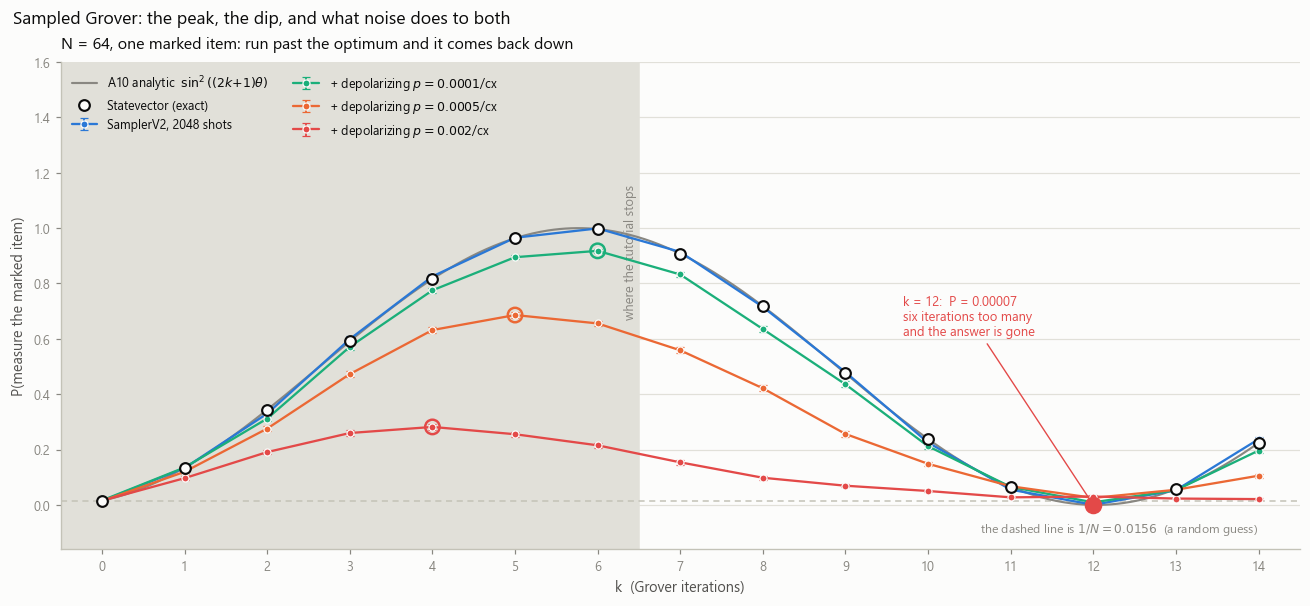

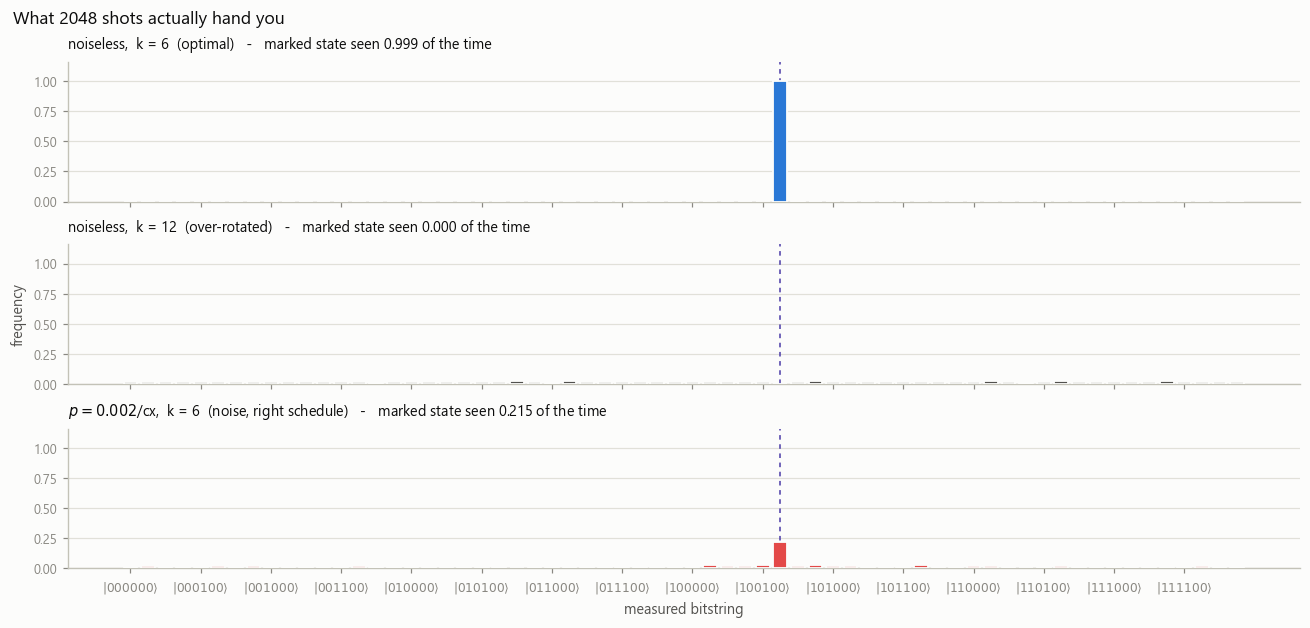

  k     exact   shots p=0      +-   p=0.0001   p=0.0005    p=0.002
  0    0.0156      0.0142  0.0026     0.0161     0.0142     0.0151
  1    0.1348      0.1333  0.0075     0.1353     0.1196     0.0967
  2    0.3439      0.3301  0.0104     0.3120     0.2759     0.1909
  3    0.5914      0.5991  0.0108     0.5713     0.4727     0.2598
  4    0.8164      0.8257  0.0084     0.7754     0.6318     0.2817
  5    0.9635      0.9653  0.0040     0.8950     0.6860     0.2554
  6    0.9966      0.9990  0.0007     0.9180     0.6558     0.2153
  7    0.9074      0.9141  0.0062     0.8325     0.5586     0.1538
  8    0.7180      0.7153  0.0100     0.6353     0.4214     0.0981
  9    0.4750      0.4795  0.0110     0.4355     0.2563     0.0693
 10    0.2381      0.2251  0.0092     0.2119     0.1484     0.0503
 11    0.0656      0.0552  0.0050     0.0649     0.0674     0.0273
 12    0.0001      0.0005  0.0005     0.0093     0.0254     0.0303
 13    0.0576      0.0532  0.0050     0.0532     0.0547     0.

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(11.8, 5.4))
kk = np.linspace(0, KS_RUN[-1], 600)
ax.axvspan(-0.5, K_OPT + 0.5, color=style.GRID, zorder=0)
ax.text(K_OPT + 0.32, 1.16, "where the tutorial stops", fontsize=8.5,
        color=style.MUTED, va="top", ha="left", rotation=90)
ax.plot(kk, analytic(kk, DIM6, 1), color=style.MUTED, lw=1.4, zorder=2,
        label=r"A10 analytic  $\sin^2((2k{+}1)\theta)$")
ax.plot(KS_RUN, P_HIT[KS_RUN], ls="none", marker="o", ms=7.0, color=style.INK,
        markerfacecolor=style.SURFACE, markeredgewidth=1.4, zorder=6,
        label="Statevector (exact)")

noise_cols = {0.0: style.BLUE, 1e-4: style.AQUA, 5e-4: style.ORANGE,
              2e-3: style.RED}
for p in P_NOISE:
    lab = (f"SamplerV2, {SHOTS} shots" if p == 0 else
           f"+ depolarizing $p = {p:g}$/cx")
    ax.errorbar(KS_RUN, hits_by_p[p], yerr=err_by_p[p], ls="-", lw=1.5,
                marker="o", ms=4.6, color=noise_cols[p],
                markeredgecolor=style.SURFACE, markeredgewidth=0.8,
                elinewidth=1.2, capsize=2.5, zorder=5, label=lab)
    kp = int(np.argmax(hits_by_p[p]))
    if p > 0:
        ax.scatter([kp], [hits_by_p[p][kp]], s=90, facecolor="none",
                   edgecolor=noise_cols[p], linewidth=1.6, zorder=7)

ax.axhline(1 / DIM6, color=style.AXIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
# The strip below the axis is the only region of a sine-filled plot with nothing
# in it, so the reference line's caption goes there.
ax.text(KS_RUN[-1], -0.115, f"the dashed line is $1/N = {1/DIM6:.4f}$  "
                            "(a random guess)",
        ha="right", va="bottom", fontsize=8, color=style.MUTED)
ax.scatter([K_WORST], [P_HIT[K_WORST]], s=110, color=style.RED, zorder=8)
grid.annotate(ax, f"k = {K_WORST}:  P = {P_HIT[K_WORST]:.5f}\n"
                  "six iterations too many\nand the answer is gone",
              xy=(K_WORST, P_HIT[K_WORST]), xytext=(9.7, 0.68),
              color=style.RED)
ax.set_xlabel("k  (Grover iterations)")
ax.set_ylabel("P(measure the marked item)")
ax.set_xticks(KS_RUN)
ax.set_xlim(-0.5, KS_RUN[-1] + 0.5)
ax.set_ylim(-0.16, 1.60)
ax.legend(loc="upper left", fontsize=8.2, ncols=2)
ax.set_title("N = 64, one marked item: run past the optimum and it comes back "
             "down", loc="left", fontsize=10.5)
fig.suptitle("Sampled Grover: the peak, the dip, and what noise does to both",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

shots_panels = [(0.0, K_OPT, style.BLUE, f"noiseless,  k = {K_OPT}  (optimal)"),
                (0.0, 12, style.INK_2, "noiseless,  k = 12  (over-rotated)"),
                (2e-3, K_OPT, style.RED,
                 f"$p = 0.002$/cx,  k = {K_OPT}  (noise, right schedule)")]
fig, axes = plt.subplots(3, 1, figsize=(11.8, 5.6), sharex=True)
for r, (axh, (p, k, col, name)) in enumerate(zip(axes, shots_panels)):
    c = counts_by_p[p][k]
    probs = np.array([c.get(format(i, "06b"), 0) for i in range(DIM6)]) / SHOTS
    grid.prob_bars(axh, probs, color=col, tick_every=4,
                   ylabel="frequency" if r == 1 else None)
    axh.set_ylim(0, 1.16)
    axh.axvline(MARK6[0], color=style.VIOLET, lw=1.0, ls=(0, (3, 3)), zorder=1)
    axh.set_title(f"{name}   -   marked state seen "
                  f"{probs[MARK6[0]]:.3f} of the time", loc="left", fontsize=9.5)
axes[-1].set_xlabel("measured bitstring")
fig.suptitle(f"What {SHOTS} shots actually hand you", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print(f"{'k':>3} {'exact':>9} {'shots p=0':>11} {'+-':>7} "
      + " ".join(f"{'p='+format(p,'g'):>10}" for p in P_NOISE[1:]))
for k in KS_RUN:
    row = (f"{k:>3} {P_HIT[k]:>9.4f} {hits_by_p[0.0][k]:>11.4f} "
           f"{err_by_p[0.0][k]:>7.4f} ")
    row += " ".join(f"{hits_by_p[p][k]:>10.4f}" for p in P_NOISE[1:])
    print(row)

---

## Part 5 — the bill A10 could not see

A10 counted **queries**: one oracle call per iteration, $\tfrac{\pi}{4}\sqrt N$ of
them, done. That is the right way to state the theorem and the wrong way to
estimate a runtime, and the difference only becomes visible once the operator is a
circuit you have to compile.

A10 said it in passing — *"the multi-controlled Z on many qubits is itself expensive
to decompose, which B22 measures"* — so here is the measurement.

The diffuser contains one MCZ on all $n$ qubits. A generic single-solution oracle
contains another. Neither is a hardware gate: an $n$-controlled operation with no
ancillas has to be decomposed into two-qubit gates, and the standard constructions
cost $O(n^2)$ CNOTs. So the cost of *one query* grows with the problem size, and
the total is

$$\underbrace{\tfrac{\pi}{4}\sqrt{N}}_{\text{queries}} \times
  \underbrace{O(n^2)}_{\text{CNOTs per query}}
  = O\!\left(\sqrt{N}\,\log^2 N\right).$$

The $\log^2$ is not the headline and it is not asymptotically fatal, but it is a
factor of a *thousand* at $n = 12$, and it is entirely invisible in the query-count
framing everybody quotes.

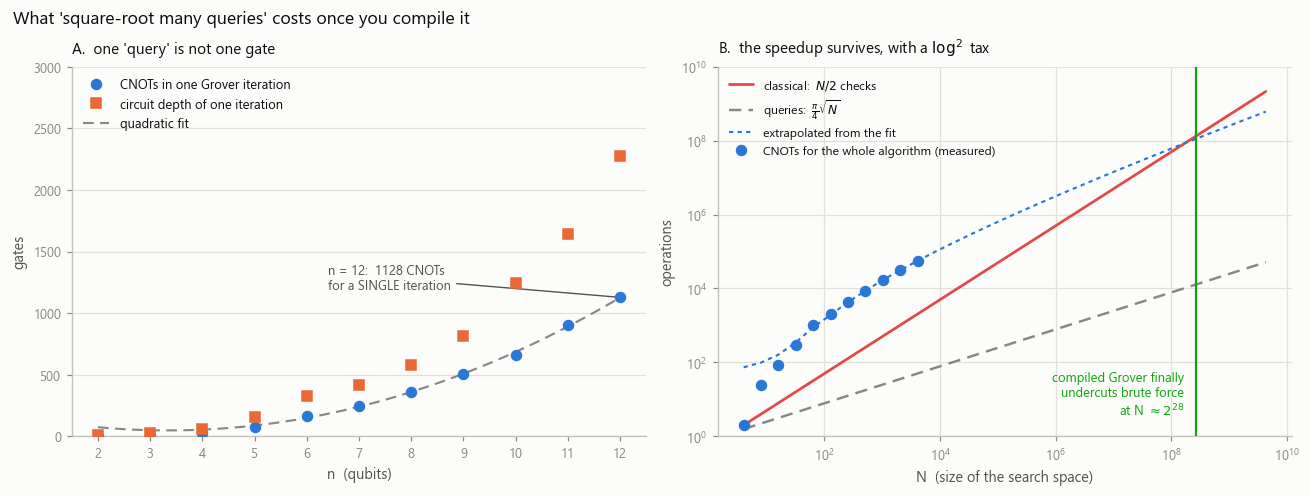

  n          N  k_opt   cx/iter  depth/iter   cx total  classical N/2
  2          4      1         2          11          2              2
  3          8      2        12          26         24              4
  4         16      3        28          57         84              8
  5         32      4        72         157        288             16
  6         64      6       168         327      1,008             32
  7        128      8       248         419      1,984             64
  8        256     12       360         581      4,320            128
  9        512     17       504         817      8,568            256
 10      1,024     25       664        1243     16,600            512
 11      2,048     35       904        1641     31,640          1,024
 12      4,096     50      1128        2273     56,400          2,048

quadratic fit to cx/iteration: 14.38 n^2 -96.10 n +208.29
extrapolated crossover with the classical N/2 line: N ~ 2^28 = 268,435,456
i.e. on OPERATION COUNT al

In [10]:
def generic_oracle(n):
    """A single-solution oracle marking |1...1>: one MCZ, nothing else.

    The cheapest honest oracle there is. A real oracle (a hash, a SAT instance)
    is far bigger, so every number below is a LOWER bound on the true cost.
    """
    qc = QuantumCircuit(n)
    return mcz(qc, list(range(n)))


NS = np.arange(2, 13)
cx_iter, depth_iter = [], []
for n in NS:
    Gn = grover_operator(generic_oracle(int(n)))
    tn = transpile(Gn, basis_gates=BASIS, optimization_level=1,
                   seed_transpiler=SEED)
    cx_iter.append(tn.count_ops().get("cx", 0))
    depth_iter.append(tn.depth())
cx_iter = np.array(cx_iter, dtype=float)
depth_iter = np.array(depth_iter, dtype=float)

k_of_n = np.array([best_k(2 ** int(n), 1) for n in NS], dtype=float)
cx_total = cx_iter * k_of_n
n_items = 2.0 ** NS

# Transpiling n = 30 is not something to do inside a notebook build, so the
# large-n curve is an EXTRAPOLATION of the measured quadratic - drawn dashed and
# labelled as such. It is the crossover point that matters, not its third digit.
fit_hi = np.polyfit(NS[3:], cx_iter[3:], 2)
NS_EXT = np.arange(2, 33)
cx_ext = np.polyval(fit_hi, NS_EXT)
k_ext = np.array([best_k(2.0 ** int(n), 1) for n in NS_EXT], dtype=float)
tot_ext = cx_ext * k_ext
n_ext = 2.0 ** NS_EXT
wins = np.flatnonzero(tot_ext < n_ext / 2)
n_cross = n_ext[wins[0]] if len(wins) else np.nan

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))

ax = axes[0]
ax.plot(NS, cx_iter, ls="none", marker="o", ms=6.5, color=style.BLUE,
        zorder=5, label="CNOTs in one Grover iteration")
ax.plot(NS, depth_iter, ls="none", marker="s", ms=6.0, color=style.ORANGE,
        zorder=5, label="circuit depth of one iteration")
fit = np.polyfit(NS[3:], cx_iter[3:], 2)
nn = np.linspace(2, 12, 200)
ax.plot(nn, np.polyval(fit, nn), color=style.MUTED, lw=1.4, ls=(0, (5, 3)),
        zorder=3, label="quadratic fit")
ax.set_xlabel("n  (qubits)")
ax.set_ylabel("gates")
ax.set_xticks(NS)
ax.set_ylim(0, max(depth_iter.max(), cx_iter.max()) * 1.32)
ax.legend(loc="upper left", fontsize=8.5)
ax.set_title("A.  one 'query' is not one gate", loc="left", fontsize=10)
grid.annotate(ax, f"n = 12:  {cx_iter[-1]:.0f} CNOTs\nfor a SINGLE iteration",
              xy=(12, cx_iter[-1]), xytext=(6.4, cx_iter.max() * 1.14),
              color=style.INK_2)

ax = axes[1]
ax.loglog(n_ext, n_ext / 2, color=style.RED, lw=1.8, zorder=4,
          label="classical:  $N/2$ checks")
ax.loglog(n_ext, (np.pi / 4) * np.sqrt(n_ext), color=style.MUTED, lw=1.6,
          ls=(0, (5, 3)), zorder=3, label=r"queries:  $\frac{\pi}{4}\sqrt{N}$")
ax.loglog(n_ext, tot_ext, color=style.BLUE, lw=1.4, ls=(0, (2, 2)), zorder=4,
          label="extrapolated from the fit")
ax.loglog(n_items, cx_total, ls="none", marker="o", ms=6.5, color=style.BLUE,
          zorder=6, label="CNOTs for the whole algorithm (measured)")
if np.isfinite(n_cross):
    ax.axvline(n_cross, color=style.GOOD, lw=1.4, zorder=5)
    ax.annotate(f"compiled Grover finally\nundercuts brute force\nat "
                f"N $\\approx 2^{{{np.log2(n_cross):.0f}}}$",
                xy=(n_cross, 3.0), xytext=(-8, 0), textcoords="offset points",
                ha="right", va="bottom", fontsize=8.5, color=style.GOOD)
ax.set_xlabel("N  (size of the search space)")
ax.set_ylabel("operations")
ax.set_ylim(1, 1e10)
ax.grid(True, which="major", axis="both")
ax.legend(loc="upper left", fontsize=8.0)
ax.set_title("B.  the speedup survives, with a $\\log^2$ tax", loc="left",
             fontsize=10)

fig.suptitle("What 'square-root many queries' costs once you compile it",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'n':>3} {'N':>10} {'k_opt':>6} {'cx/iter':>9} {'depth/iter':>11} "
      f"{'cx total':>10} {'classical N/2':>14}")
for i, n in enumerate(NS):
    print(f"{n:>3} {2**int(n):>10,} {k_of_n[i]:>6.0f} {cx_iter[i]:>9.0f} "
          f"{depth_iter[i]:>11.0f} {cx_total[i]:>10,.0f} "
          f"{2**int(n)//2:>14,}")
print(f"\nquadratic fit to cx/iteration: {fit_hi[0]:.2f} n^2 {fit_hi[1]:+.2f} n "
      f"{fit_hi[2]:+.2f}")
print(f"extrapolated crossover with the classical N/2 line: "
      f"N ~ 2^{np.log2(n_cross):.0f} = {n_cross:,.0f}")
print("i.e. on OPERATION COUNT alone - before any error correction, routing or "
      "shot\noverhead - compiled Grover does not overtake brute force until "
      "tens of millions\nof items. The asymptotic win is real; the constant is "
      "not small.")

Panel B is the honest version of the quadratic speedup, and it is not a flattering
picture. Count *queries* (the grey dashed line) and Grover beats brute force from
$N = 4$ upward. Count the CNOTs those queries compile into (blue) and the crossover
moves out to somewhere around $N \approx 2^{26}$ — tens of millions of items —
because each query costs $O(n^2)$ gates and $\sqrt N$ of them is not free.

Two caveats on that number, in opposite directions. It is *pessimistic* in that a
classical "check" of a real predicate is not one operation either — we are comparing
CNOTs to idealised checks. It is wildly *optimistic* in that it ignores routing
overhead, error correction, and the fact that every one of those CNOTs can fail.

None of this touches the theorem. It does mean that "Grover gives a quadratic
speedup" and "Grover will be faster than your CPU" are different claims, and only
the first one is proved.

## Deep dive — `state_preparation`, and why Grover is really amplitude amplification

*Skip on a first read.*

A10 closed by verifying numerically that nothing in the derivation needed the start
state to be uniform: replace $H^{\otimes n}$ with any unitary $A$, replace the
diffuser with $2A|0\rangle\langle 0|A^\dagger - I$, and the same two-reflection
argument gives the same rotation with $\sin\theta = \sqrt{p_0}$, where $p_0$ is
whatever success probability $A$ started you with.

In Qiskit that is not a derivation, it is an argument name. `state_preparation=A`
and `grover_operator` builds the generalised reflection for you. Below: a start
state with a *deliberately lopsided* distribution, amplified by the same operator,
obeying the same sine law.

In [11]:
N_AA = 4
TARGET_AA = 6

# A biased start: a layer of Ry with unequal angles. Nothing uniform about it.
angles = rng.uniform(0.5, 2.4, size=N_AA)
prep = QuantumCircuit(N_AA, name="A")
for q, a in enumerate(angles):
    prep.ry(float(a), q)

oracle_aa = oracle_by_hand(N_AA, TARGET_AA)
G_AA = grover_operator(oracle_aa, state_preparation=prep)

sv = Statevector(prep)
p0 = float(np.abs(sv.data[TARGET_AA]) ** 2)
th_aa = np.arcsin(np.sqrt(p0))
print(f"start state P(|{format(TARGET_AA, '04b')}>) = {p0:.6f}  (uniform would "
      f"be {1/2**N_AA:.6f})")
print(f"theta = asin(sqrt(p0)) = {np.degrees(th_aa):.3f} deg   "
      f"optimal k = {int(np.round(np.pi/(4*th_aa) - 0.5))}")
print(f"\n{'k':>3} {'Qiskit P':>13} {'sin^2((2k+1)theta)':>21} {'diff':>10}")
aa_meas, aa_ana = [], []
for k in range(9):
    got = float(np.abs(sv.data[TARGET_AA]) ** 2)
    want = float(np.sin((2 * k + 1) * th_aa) ** 2)
    aa_meas.append(got)
    aa_ana.append(want)
    print(f"{k:>3} {got:>13.9f} {want:>21.9f} {abs(got-want):>10.1e}")
    sv = sv.evolve(G_AA)
print("\nSame sine law, from a start state that is not uniform at all - which is "
      "why\nGrover shows up inside larger algorithms as a subroutine.")

start state P(|0110>) = 0.105445  (uniform would be 0.062500)
theta = asin(sqrt(p0)) = 18.949 deg   optimal k = 2

  k      Qiskit P    sin^2((2k+1)theta)       diff
  0   0.105445073           0.105445073    0.0e+00
  1   0.700916265           0.700916265    7.8e-16
  2   0.993160100           0.993160100    2.9e-15
  3   0.541115593           0.541115593    1.4e-15
  4   0.027018506           0.027018506    4.5e-17
  5   0.226755754           0.226755754    2.1e-15
  6   0.838879380           0.838879380    7.1e-15
  7   0.939558604           0.939558604    8.1e-15
  8   0.376846073           0.376846073    2.2e-15

Same sine law, from a start state that is not uniform at all - which is why
Grover shows up inside larger algorithms as a subroutine.


---

## Honest limits

**`grover_operator()` does not know when to stop.** It gives you $G$. Choosing $k$
is entirely on you, there is no `optimal_iterations` helper in the SDK any more
(the one that existed lived in `qiskit.algorithms`, which is gone), and Figures 3
and 4 are what happens if you guess wrong. The formula is
$k = \operatorname{round}\!\big(\tfrac{\pi}{4\theta} - \tfrac12\big)$ with
$\sin\theta = \sqrt{M/N}$ — and it needs $M$.

**Every oracle here is a cheat, and a specific kind of cheat.** We built the oracle
by *already knowing the answer* — `oracle_by_hand(n, 11)` takes the marked index as
an argument. `PhaseOracleGate("a & b & ~c & d")` is only marginally better: it takes
a formula whose satisfying assignment we can read off by eye. A real Grover oracle
is a reversible circuit for a function you cannot invert, and building it is
usually harder than everything else in this notebook put together.

**The gate counts in Figure 5 are lower bounds twice over.** They assume the
cheapest possible oracle (one MCZ), and they assume all-to-all connectivity. Route
the same circuits onto a real device's coupling map and the SWAP overhead multiplies
the CNOT count again — often by 3–10x at these sizes.

**The noise model is one channel on one gate type.** Depolarizing on `cx`, nothing
on the single-qubit gates, no readout error, no idle decoherence, no crosstalk.
Every one of those omissions makes the picture more optimistic than reality. The
$p = 0.002$ curve — peak $P \approx 0.28$ instead of $0.996$ — is what a *charitable*
model of a good current device does to a six-qubit Grover.

**Noise moves the optimum, and you cannot see it move.** This is the nastiest
interaction in the notebook. The noiseless optimum is $k = 6$; at $p = 0.002$ the
best measured $k$ is smaller. To pick the right $k$ you now need to know both $M$
*and* your own error rate — and if you get it wrong you cannot tell from the output
whether you over-rotated or just decohered. Both look like a flat distribution.

**Amplitudes are real here, and that is why the middle column of Figure 3 works.**
A phase oracle that marks with $e^{i\phi}$ instead of $-1$, or a complex
`state_preparation`, immediately breaks the signed-amplitude heatmap: there is no
"sign" to colour. The probability panel survives; the diverging colormap does not.
Same caveat A10 ended on.

**The $\sqrt N$ is optimal and that is the ceiling.** BBBV (1997) proves
$\Omega(\sqrt N)$ queries for any quantum algorithm that only queries the oracle.
Grover matches it, constant included. There is no faster unstructured search
waiting to be found — and quadratic speedups lose most of their margin to error
correction overhead, which is why the standard cryptographic response to Grover is
simply "double the key length".

## Checkpoint

Track B closes by asserting against the from-scratch Track A result it mirrors.
Here that is A10's `grover_states`: rebuilt inline in raw NumPy — no `quantum_info`
anywhere in the block — and asserted `np.allclose` against every statevector Qiskit
produced, at every iteration, for both $M = 1$ and $M = 4$.

In [12]:
# ---------------------------------------------------------------- Track A
# A10's implementation, verbatim in spirit: a diagonal of +-1 and one line of
# inversion about the mean. Nothing from qiskit is used to produce these.
def a10_oracle_diag(n, marked):
    d = np.ones(2 ** n)
    d[list(marked)] = -1.0
    return d


def a10_grover_states(n, marked, kmax):
    """A10's grover_states: every state from k = 0 to k = kmax."""
    d = a10_oracle_diag(n, marked)
    psi = np.ones(2 ** n) / np.sqrt(2 ** n)
    out = [psi.copy()]
    for _ in range(kmax):
        psi = d * psi                     # oracle: sign flip on the marked
        psi = 2.0 * psi.mean() - psi      # diffuser: inversion about the mean
        out.append(psi.copy())
    return np.array(out)


# 1. THE CROSS-TRACK ASSERTION: Qiskit's grover_operator trajectory equals A10's
#    NumPy trajectory, amplitude for amplitude, at every one of 37 iterations.
A10_TRAJ = a10_grover_states(N6, MARK6, KMAX)
assert np.allclose(TRAJ, A10_TRAJ, atol=1e-12), np.abs(TRAJ - A10_TRAJ).max()

A10_TRAJ_M4 = a10_grover_states(N6, MARK6_M4, KMAX)
assert np.allclose(TRAJ_M4, A10_TRAJ_M4, atol=1e-12)

# 2. Same at n = 4, and the operator itself matches A10's D @ diag(oracle).
assert np.allclose(Operator(G4).data, G_NP)
a10_4 = a10_grover_states(N_QUBITS, MARKED, 6)
sv4 = Statevector(uniform_circuit(N_QUBITS))
for k in range(7):
    assert np.allclose(sv4.data, a10_4[k], atol=1e-12), k
    sv4 = sv4.evolve(G4)

# 3. Endianness, the A10 contract: the predicate q0=1,q1=1,q2=0,q3=1 is index 11,
#    printed "1011", and all three oracle constructions agree on it.
assert MARKED == [11]
assert format(11, "04b") == "1011"
assert [(11 >> q) & 1 for q in range(4)] == [1, 1, 0, 1]
assert np.allclose(diag_hand, diag_expr)
assert np.allclose(diag_hand, diag_anc)
assert [i for i, v in enumerate(diag_expr) if v < 0] == MARKED
assert MARK6 == [37] and format(37, "06b") == "100101"
assert MARK6_M4 == [5, 21, 37, 53]

# 4. The oracle is diagonal, real, +-1, and its own inverse - it moves no
#    probability whatsoever.
U_expr = Operator(EXPRC).data
assert np.allclose(U_expr, np.diag(np.diag(U_expr)))
assert np.allclose(np.diag(U_expr).imag, 0.0)
assert np.allclose(np.abs(np.diag(U_expr).real), 1.0)
assert np.allclose(U_expr @ U_expr, np.eye(N))
psi_u = Statevector(uniform_circuit(N_QUBITS)).data
assert np.allclose(np.abs(psi_u) ** 2, np.abs(U_expr @ psi_u) ** 2)

# 5. G is unitary and is a ROTATION, not a reflection: G @ G != I. That single
#    inequality is why over-rotation exists.
assert np.allclose(G_QK.conj().T @ G_QK, np.eye(N))
assert not np.allclose(G_QK @ G_QK, np.eye(N))

# 6. Normalization holds all the way out to k = 36 on 64 states.
assert np.allclose(np.sum(TRAJ ** 2, axis=1), 1.0)
assert np.allclose(np.sum(TRAJ_M4 ** 2, axis=1), 1.0)

# 7. ANALYTIC: the Qiskit success probability is sin^2((2k+1)theta) exactly, for
#    both M = 1 and M = 4, at every k.
ks = np.arange(KMAX + 1)
assert np.allclose(P_HIT, analytic(ks, DIM6, 1), atol=1e-12)
assert np.allclose(P_HIT_M4, analytic(ks, DIM6, 4), atol=1e-12)
assert K_OPT == 6 and K_OPT_M4 == 3
assert np.isclose(P_HIT[K_OPT], analytic(K_OPT, DIM6, 1), atol=1e-12)
assert int(np.argmax(TRAJ[K_OPT] ** 2)) == MARK6[0]

# 8. THE OVER-ROTATION DIP - the point of the notebook.
assert P_HIT[K_OPT + 1] < P_HIT[K_OPT]                  # one step too far hurts
assert P_HIT[K_OPT] == P_HIT[:13].max()                 # best in the first period
assert P_HIT[K_WORST] < P_HIT[0]                        # worse than a coin flip
assert P_HIT[K_WORST] < 1e-3
assert TRAJ[18][MARK6[0]] < -0.99                       # sign flipped, P near 1
assert P_HIT[18] > 0.99
# periodic, not convergent: it comes back to where it started
k_back = int(np.round(np.pi / np.arcsin(np.sqrt(1 / DIM6))))
assert abs(P_HIT[k_back] - P_HIT[0]) < 5e-3
# M = 4 oscillates twice as fast, so the M = 1 schedule lands in its trough
assert P_HIT_M4[K_OPT] < P_HIT_M4[0]

# 9. The SAMPLED run reproduces the exact curve to within binomial noise, and
#    reproduces the dip. 4 sigma, with a floor for the k where P is ~0.
sig = np.maximum(err_by_p[0.0], 1.0 / SHOTS)
assert np.all(np.abs(hits_by_p[0.0] - P_HIT[KS_RUN]) < 4 * sig + 0.01)
assert int(np.argmax(hits_by_p[0.0])) == K_OPT
assert hits_by_p[0.0][12] < hits_by_p[0.0][0]

# 10. NOISE: strictly monotone damage at the peak, and the optimum moves EARLIER
#     (or at best stays put) as p grows. Never later.
peaks = [hits_by_p[p].max() for p in P_NOISE]
assert peaks == sorted(peaks, reverse=True), peaks
arg_peaks = [int(np.argmax(hits_by_p[p])) for p in P_NOISE]
assert arg_peaks[-1] <= arg_peaks[0], arg_peaks
assert hits_by_p[2e-3].max() < 0.5

# 11. AMPLITUDE AMPLIFICATION from a non-uniform state_preparation obeys the
#     same law, which is the general statement Grover is a special case of.
assert np.allclose(aa_meas, aa_ana, atol=1e-9)
assert not np.isclose(p0, 1 / 2 ** N_AA)          # the start really is lopsided

# 12. Cost: one iteration is NOT one gate, and the count grows with n.
assert cx_iter[-1] > 1000
assert np.all(np.diff(cx_iter) > 0)
assert CX_PER_ITER == 168

print("B22 checkpoint passed.")
print(f"  max |Qiskit statevector - A10 NumPy| over {KMAX + 1} iterations x "
      f"{DIM6} states: {np.abs(TRAJ - A10_TRAJ).max():.2e}")
print(f"  P at the optimal k = {K_OPT}: {P_HIT[K_OPT]:.9f}  "
      f"(analytic {analytic(K_OPT, DIM6, 1):.9f})")
print(f"  P at k = {K_WORST}:            {P_HIT[K_WORST]:.9f}  "
      f"(a random guess: {1/DIM6:.9f})")

B22 checkpoint passed.
  max |Qiskit statevector - A10 NumPy| over 37 iterations x 64 states: 3.17e-13
  P at the optimal k = 6: 0.996585681  (analytic 0.996585681)
  P at k = 12:            0.000070506  (a random guess: 0.015625000)


---

**Next:** [B23 — QFT and Phase Estimation in Qiskit](B23_QFT_Phase_Estimation.ipynb).
Part 2 found $e^{\pm 2i\theta}$ sitting in the spectrum of the Grover operator, and
$\theta$ is precisely the number you need in order to know when to stop. Phase
estimation is the machine that reads an eigenphase off a unitary — so the fix for
this notebook's central limitation is the subject of the next one.